In [8]:
## import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans


In [67]:
## load the dataset
df=pd.read_csv("https://raw.githubusercontent.com/codebasics/py/refs/heads/master/ML/13_kmeans/income.csv")
df.head()
df.to_csv('income.csv',index=False)

<Axes: xlabel='Age', ylabel='Income($)'>

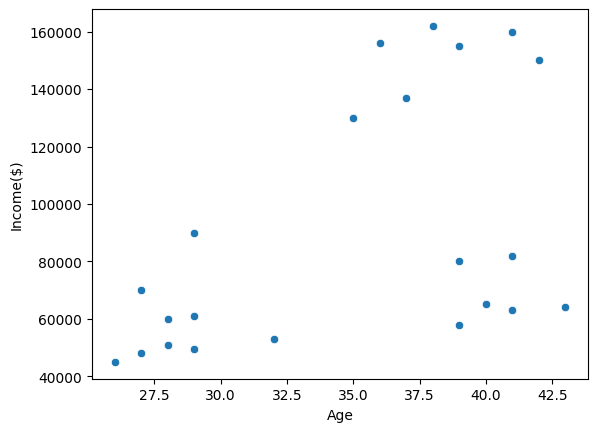

In [41]:
sns.scatterplot(data=df,x='Age',y='Income($)')

In [42]:
km=KMeans(n_clusters=3)
y_prediction=km.fit_predict(df[['Age','Income($)']])
y_prediction
df['cluster']=y_prediction
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


<Axes: xlabel='Age', ylabel='Income($)'>

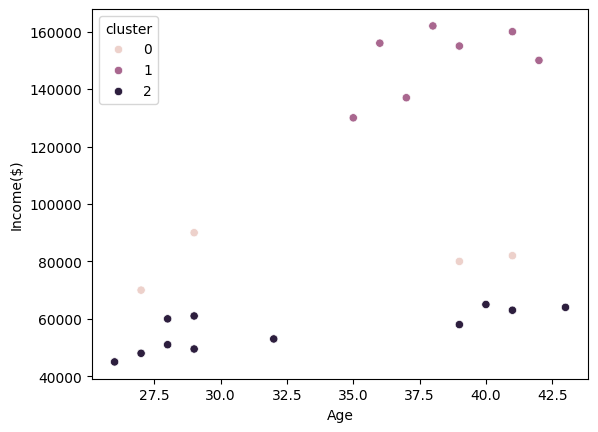

In [43]:
sns.scatterplot(data=df,x='Age',y='Income($)',hue='cluster')

In [44]:
scaler=MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.transform(df[['Income($)']])
df

,Name,Age,Income($),cluster
0,Rob,27,0.213675,0
1,Michael,29,0.384615,0
2,Mohan,29,0.136752,2
3,Ismail,28,0.128205,2
4,Kory,42,0.897436,1
5,Gautam,39,0.940171,1
6,David,41,0.982906,1
7,Andrea,38,1.000000,1
8,Brad,36,0.948718,1
9,Angelina,35,0.726496,1


In [45]:
scaler.fit(df[['Age']])
df['Age']=scaler.transform(df[['Age']])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


<Axes: xlabel='Age', ylabel='Income($)'>

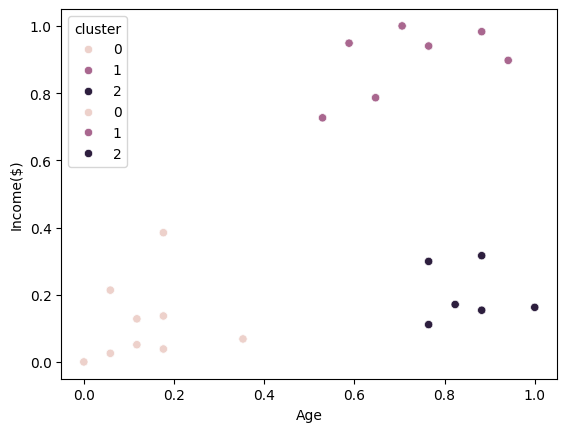

In [ ]:
y_prediction=km.fit_predict(df[['Age','Income($)']])
df['cluster']=y_prediction
sns.scatterplot(data=df,x='Age',y='Income($)',hue='cluster')



In [47]:
df['cluster']

0     0
1     0
2     0
3     0
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    0
12    0
13    0
14    0
15    0
16    1
17    1
18    1
19    1
20    1
21    1
Name: cluster, dtype: int32

In [48]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ],
       [0.72268908, 0.8974359 ]])

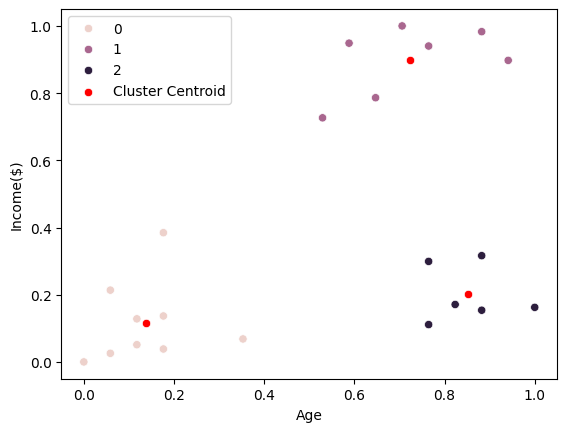

In [59]:
sns.scatterplot(data=df,x='Age',y='Income($)',hue='cluster')
sns.scatterplot(x=km.cluster_centers_[:,0],y=km.cluster_centers_[:,1],color='red',label='Cluster Centroid')
plt.legend()

How to identify K  using elbow plot


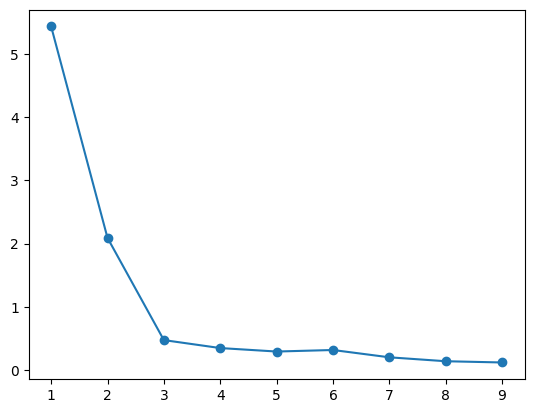

In [66]:
sse=[]
k_range=range(1,10)
for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)
plt.plot(k_range,sse, marker='o')

In [68]:
df.to_csv('Cleaned_income.csv',index=False)